# b) Creating a long trajectory of the Lorenz 63 System

In [18]:
import numpy as np
from scipy.integrate import odeint, solve_ivp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sympy as smp
import pandas as pd

In [3]:
def Lorenz63(t,X0):
    x,y,z = X0
    
    xdot = 10*(y-x)
    ydot = 28*x-y-x*z
    zdot = -(8/3)*z+x*y
    return [xdot,ydot,zdot]

In [4]:
delta_t = 0.02
N = 10000
T = N*delta_t
tspan = (0,T)
X0 = [1,1,1]


In [5]:
X1 = solve_ivp(Lorenz63,tspan,X0,atol=1,rtol=1,max_step=delta_t)
X1 = X1.y.T

In [6]:
def Lorenz(X0):
    x,y,z = X0
    xdot = 10*(y-x)
    ydot = 28*x-y-x*z
    zdot = -(8/3)*z+x*y
    return [xdot,ydot,zdot]

In [7]:
Xdot = np.zeros((N+1,3))
for n in range(N+1):
    D = X1[n,:]
    dX = Lorenz(D)
    Xdot[n] = dX
    

In [19]:
XX = pd.DataFrame(X1,columns = [r'$x$',r'$y$',r'$z$'])
XX.head(10)

XXdot = pd.DataFrame(Xdot,columns = [r'$\dot{x}$',r'$\dot{y}$',r'$\dot{z}$'])
XXdot.head(10)

,$\dot{x}$,$\dot{y}$,$\dot{z}$
0,0.000000,26.000000,-1.666667
1,4.751771,26.822406,-0.996567
2,9.016772,30.002273,-0.085810
3,13.289806,35.358454,1.266557
4,17.964291,42.923813,3.341768
5,23.383110,52.879557,6.567627
6,29.868654,65.488862,11.605406
7,37.732967,80.998352,19.469352
8,47.261486,99.457921,31.681592
9,58.653400,120.378565,50.438162


# c) Plot the Butterfly Attractor

C:\Users\troy-\AppData\Local\Temp\ipykernel_4252\319399589.py:8: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 12


Text(0.5, 0.92, '$\\Delta t = 0.02,N=10000$')

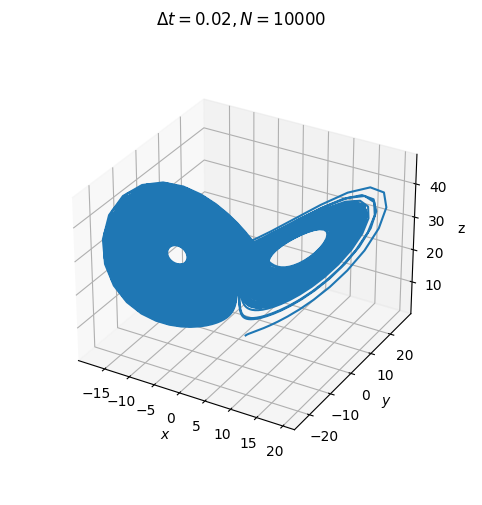

In [20]:
fig = plt.figure(figsize=(8,6))
ax=plt.axes(projection='3d')
ax.plot(X1[:,0],
       X1[:,1],
       X1[:,2])
ax.set(xlabel='$x$', ylabel='$y$')
ax.set_zlabel('z')
ax.dist = 12
ax.set_title(r'$\Delta t = 0.02,N=10000$')

# d) Solving $\dot{X}=\Theta(X)\Xi$ and Creating a Vector Field

In [21]:
Xdot

array([[  0.        ,  26.        ,  -1.66666667],
       [  4.75177101,  26.82240608,  -0.99656698],
       [  9.01677213,  30.00227262,  -0.08580993],
       ...,
       [-14.07220291,  12.56166707, -56.40042355],
       [ -9.02968003,  14.80765439, -53.06921976],
       [ -4.51123237,  16.91611058, -49.66662197]])

In [22]:
Theta = np.zeros((N+1,20))
Theta[:,0] = 1
xx,yy,zz = X1[:,0],X1[:,1],X1[:,2]
Theta[:,1:4] = X1 #X^P1
Theta[:,4:10] = np.array([xx**2,yy**2,zz**2,xx*yy,xx*zz,yy*zz]).T #X^P2
Theta[:,10:] = np.array([xx**3,yy**3,zz**3,xx**2*yy,xx**2*zz,yy**2*zz,xx*yy**2,xx*yy*zz,yy*zz**2,xx*zz**2]).T #X^P3

In [23]:
lam = 0.025
M = np.linalg.pinv(Theta) #pseudo inverse of theta
Xi =np.matmul(M,Xdot) #initial guess for Xi

In [24]:
for k in range(10):
    print(Xi)
    tooSmall = np.abs(Xi)<lam
    Xi[tooSmall]=0
    for l in range(3):
        survivors = ~tooSmall[:,l]
        Q = np.linalg.pinv(Theta[:,survivors])
        Xi[survivors,l] = np.matmul(Q,Xdot[:,l])

[[-9.48641166e-11  2.41126008e-10  1.41367473e-12]
 [-1.00000000e+01  2.80000000e+01 -7.54951657e-15]
 [ 1.00000000e+01 -1.00000000e+00  1.59428026e-13]
 [ 9.81353887e-13 -2.62748157e-12 -2.66666667e+00]
 [-2.60291788e-13  7.35508876e-13  6.66047079e-14]
 [ 2.64829825e-13 -3.75805290e-13  5.38943890e-14]
 [ 1.52735463e-13 -2.02006814e-13  3.19518717e-14]
 [-2.45692355e-13 -9.78384040e-14  1.00000000e+00]
 [-3.46805917e-14 -1.00000000e+00 -4.99600361e-15]
 [ 1.80758186e-14 -6.14786000e-15 -1.28369537e-14]
 [ 6.55725474e-16 -3.15719673e-16 -3.71230824e-16]
 [-1.65991353e-16 -1.76616534e-16  1.12973866e-16]
 [-2.63992387e-15 -7.75434946e-16 -1.01028669e-15]
 [ 3.01755149e-15 -1.29757316e-15 -3.28730099e-15]
 [ 7.61500238e-15  2.34187669e-16  2.92181643e-15]
 [-3.34498054e-15  7.06682976e-16  1.49511480e-15]
 [-1.33942336e-15  6.21681526e-16  2.23085439e-15]
 [-5.26488575e-16 -4.67941658e-16 -1.59811400e-16]
 [-3.00757683e-16  2.31151903e-16  4.25766193e-16]
 [ 3.96384314e-16 -7.87564458e-

In [25]:
xi2 = pd.DataFrame(Xi,columns = [r'$\xi_1$',r'$\xi_2$',r'$\xi_3$'],
                   index = ['$1$',r'$x$',r'$y$',r'$z$',r'$x^2$',r'$y^2$',r'$z^2$',r'$xy$',r'$xz$',r'$yz$',r'$x^3$',
                            r'$y^3$',r'$z^3$',r'$x^2y$',r'$x^2z$',r'$y^2z$',r'$xy^2$',r'$xyz$',r'$yz^2$',r'$xz^2$'])

In [26]:
xi2

,$\xi_1$,$\xi_2$,$\xi_3$
$1$,0.0,0.0,0.000000
$x$,-10.0,28.0,0.000000
$y$,10.0,-1.0,0.000000
$z$,0.0,0.0,-2.666667
$x^2$,0.0,0.0,0.000000
$y^2$,0.0,0.0,0.000000
$z^2$,0.0,0.0,0.000000
$xy$,0.0,0.0,1.000000
$xz$,0.0,-1.0,0.000000
$yz$,0.0,0.0,0.000000


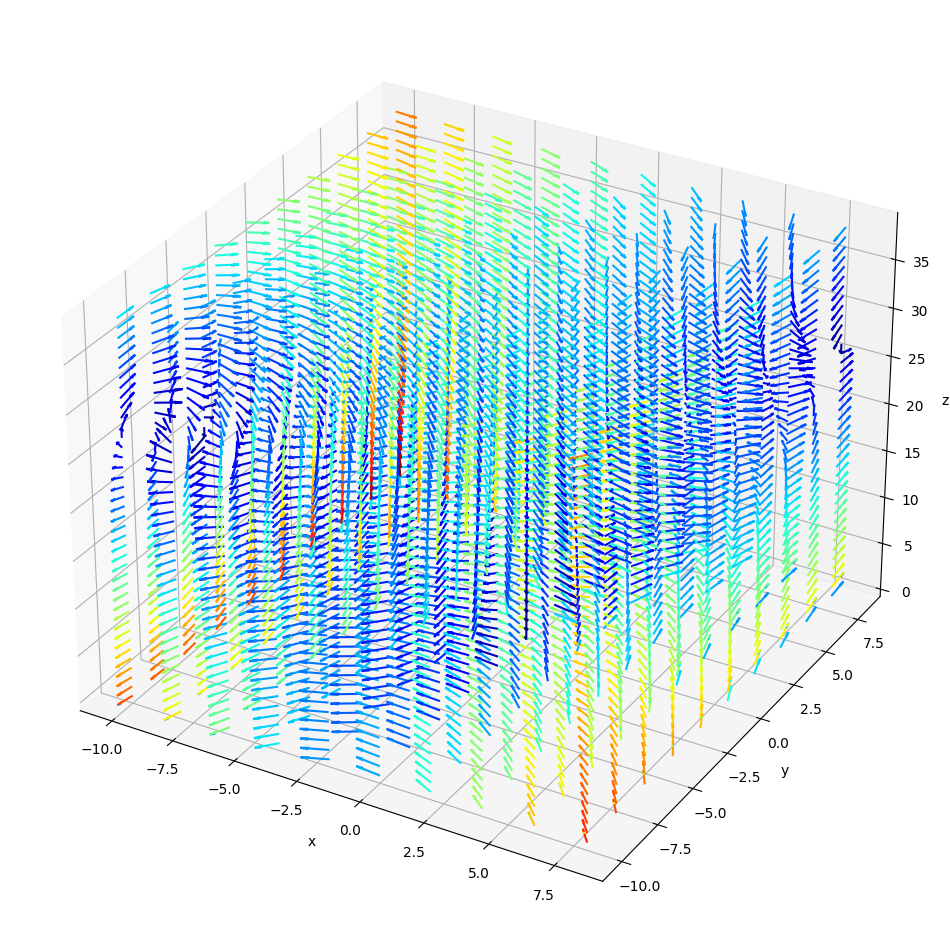

In [58]:
fig = plt.figure(figsize=(12,15))
ax = fig.add_subplot(1,1,1,projection = '3d')
x,y,z = np.meshgrid(np.arange(-10,10,2),np.arange(-10,10,2),np.arange(0,40,1))
u = -10*x+10*y
v = 28*x-y-x*z
w = -(8/3)*z+x*y
c = np.sqrt(v ** 2 + u ** 2 +w ** 2)
c = (c.ravel() - c.min()) / c.ptp()
c = np.concatenate((c, np.repeat(c, 2)))
c = plt.cm.jet(c)
q = ax.quiver(x,y,z,u,v,w,colors=c,normalize = True)
ax.set(xlabel = 'x',ylabel = 'y',zlabel='z')
q.set_array(np.random.rand(np.prod(x.shape)))
plt.show()

# e) Affecting the accuracy

## Adding noise to the derivative

In [186]:
Adot = Xdot + np.random.normal(loc=0,size=(10001,3))
Bdot = Xdot + np.random.normal(loc=0,size=(10001,3),scale = 5)
Cdot = Xdot + np.random.normal(loc=0,size=(10001,3),scale = 20)

In [187]:
Theta = np.zeros((N+1,20))
Theta[:,0] = 1
xx,yy,zz = X1[:,0],X1[:,1],X1[:,2]
Theta[:,1:4] = X1 #X^P1
Theta[:,4:10] = np.array([xx**2,yy**2,zz**2,xx*yy,xx*zz,yy*zz]).T #X^P2
Theta[:,10:] = np.array([xx**3,yy**3,zz**3,xx**2*yy,xx**2*zz,yy**2*zz,xx*yy**2,xx*yy*zz,yy*zz**2,xx*zz**2]).T #X^P3

In [188]:
lam = 0.025
M = np.linalg.pinv(Theta) #pseudo inverse of theta
XiA =np.matmul(M,Adot) #initial guess for XiA
XiB =np.matmul(M,Bdot) #initial guess for XiB
XiC=np.matmul(M,Cdot) #initial guess for XiC

In [189]:
for a in range(10):
    tooSmall = np.abs(XiA)<lam
    XiA[tooSmall]=0
    for l in range(3):
        survivors = ~tooSmall[:,l]
        Q = np.linalg.pinv(Theta[:,survivors])
        XiA[survivors,l] = np.matmul(Q,Adot[:,l])
        
for b in range(10):
    tooSmall = np.abs(XiB)<lam
    XiB[tooSmall]=0
    for l in range(3):
        survivors = ~tooSmall[:,l]
        Q = np.linalg.pinv(Theta[:,survivors])
        XiB[survivors,l] = np.matmul(Q,Bdot[:,l])

for c in range(10):
    tooSmall = np.abs(XiC)<lam
    XiC[tooSmall]=0
    for l in range(3):
        survivors = ~tooSmall[:,l]
        Q = np.linalg.pinv(Theta[:,survivors])
        XiC[survivors,l] = np.matmul(Q,Cdot[:,l])

In [190]:
u0 = [1,1,1]
a1,b1,c1 = XiA[:,0],XiA[:,1],XiA[:,2]
a2,b2,c2 = XiB[:,0],XiB[:,1],XiB[:,2]
a3,b3,c3 = XiC[:,0],XiC[:,1],XiC[:,2]

In [191]:
def Dynamic_Noise1(t,U0):
    x,y,z = U0
    v = np.array([1,x,y,z,x**2,y**2,z**2,x*y,x*z,y*z,x**3,y**3,z**3,x**2*y,x**2*z,y**2*z,x*y**2,x*y*z,y*z**2,x*z**2])
    xdot = np.dot(a1,v)
    ydot = np.dot(b1,v)
    zdot = np.dot(c1,v)
    return [xdot,ydot,zdot]

In [192]:
def Dynamic_Noise2(t,U0):
    x,y,z = U0
    v = np.array([1,x,y,z,x**2,y**2,z**2,x*y,x*z,y*z,x**3,y**3,z**3,x**2*y,x**2*z,y**2*z,x*y**2,x*y*z,y*z**2,x*z**2])
    xdot = np.dot(a2,v)
    ydot = np.dot(b2,v)
    zdot = np.dot(c2,v)
    return [xdot,ydot,zdot]

In [193]:
def Dynamic_Noise3(t,U0):
    x,y,z = U0
    v = np.array([1,x,y,z,x**2,y**2,z**2,x*y,x*z,y*z,x**3,y**3,z**3,x**2*y,x**2*z,y**2*z,x*y**2,x*y*z,y*z**2,x*z**2])
    xdot = np.dot(a3,v)
    ydot = np.dot(b3,v)
    zdot = np.dot(c3,v)
    return [xdot,ydot,zdot]

In [194]:
tspan = (0,T)
Xhat1= solve_ivp(Dynamic_Noise1,tspan,u0,atol=1,rtol=1,max_step=0.02)
Xhat2= solve_ivp(Dynamic_Noise2,tspan,u0,atol=1,rtol=1,max_step=0.02)
Xhat3= solve_ivp(Dynamic_Noise3,tspan,u0,atol=1,rtol=1,max_step=0.02)

C:\Users\troy-\AppData\Local\Temp\ipykernel_4252\3734204979.py:8: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 15
C:\Users\troy-\AppData\Local\Temp\ipykernel_4252\3734204979.py:15: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 15
C:\Users\troy-\AppData\Local\Temp\ipykernel_4252\3734204979.py:23: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 15
C:\Users\troy-\AppData\Local\Temp\ipykernel_4252\3734204979.py:31: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 15


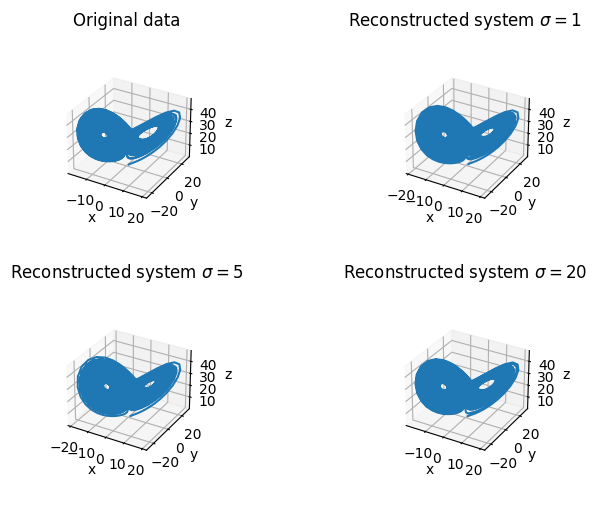

In [195]:
fig = plt.figure(figsize=(8,6))
ax=fig.add_subplot(2,2,1,projection='3d')
ax.plot(X1[:,0],
       X1[:,1],
       X1[:,2])
ax.set_title('Original data')
ax.set(xlabel = 'x',ylabel='y',zlabel='z')
ax.dist = 15
ax=fig.add_subplot(2,2,2,projection='3d')
ax.plot(Xhat1.y[0,:],
       Xhat1.y[1,:],
       Xhat1.y[2,:])
ax.set_title(r'Reconstructed system $\sigma = 1$')
ax.set(xlabel = 'x',ylabel='y',zlabel='z')
ax.dist = 15

ax=fig.add_subplot(2,2,3,projection='3d')
ax.plot(Xhat2.y[0,:],
       Xhat2.y[1,:],
       Xhat2.y[2,:])
ax.set_title(r'Reconstructed system $\sigma = 5$')
ax.set(xlabel = 'x',ylabel='y',zlabel='z')
ax.dist = 15

ax=fig.add_subplot(2,2,4,projection='3d')
ax.plot(Xhat3.y[0,:],
       Xhat3.y[1,:],
       Xhat3.y[2,:])
ax.set_title(r'Reconstructed system $\sigma = 20$')
ax.set(xlabel = 'x',ylabel='y',zlabel='z')
ax.dist = 15

In [178]:
XiC

array([[ -0.10943736,   0.12625275,   0.07523204],
       [-10.00158951,  27.69212668,   0.04013153],
       [ 10.04014858,  -0.93339073,   0.        ],
       [  0.        ,   0.        ,  -2.66476032],
       [  0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   1.00042461],
       [  0.        ,  -0.99154029,   0.        ],
       [  0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ],
       [  0.        ,   0.     

## Adding noise to the State

In [260]:
A1 = X1 + np.random.normal(loc=0,size=(10001,3),scale = 5)

In [261]:
ThetaA = np.zeros((N+1,20))
ThetaA[:,0] = 1
xx,yy,zz = A1[:,0],A1[:,1],A1[:,2]
ThetaA[:,1:4] = A1 #X^P1
ThetaA[:,4:10] = np.array([xx**2,yy**2,zz**2,xx*yy,xx*zz,yy*zz]).T #X^P2
ThetaA[:,10:] = np.array([xx**3,yy**3,zz**3,xx**2*yy,xx**2*zz,yy**2*zz,xx*yy**2,xx*yy*zz,yy*zz**2,xx*zz**2]).T #X^P3

In [262]:
lam = 0.025
M = np.linalg.pinv(Theta) #pseudo inverse of theta
XiA1 =np.matmul(M,Adot) #initial guess for XiA1

In [263]:
for a in range(10):
    tooSmall = np.abs(XiA1)<lam
    XiA1[tooSmall]=0
    for l in range(3):
        survivors = ~tooSmall[:,l]
        Q = np.linalg.pinv(ThetaA[:,survivors])
        XiA[survivors,l] = np.matmul(Q,Xdot[:,l])

In [264]:
u0 = A1[0,:]
a1,b1,c1 = XiA[:,0],XiA[:,1],XiA[:,2]

In [265]:
tspan = (0,T)
Ahat1= solve_ivp(Dynamic_Noise1,tspan,u0,atol=1,rtol=1,max_step=0.02)

C:\Users\troy-\AppData\Local\Temp\ipykernel_4252\1387378496.py:8: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 15
C:\Users\troy-\AppData\Local\Temp\ipykernel_4252\1387378496.py:15: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 15


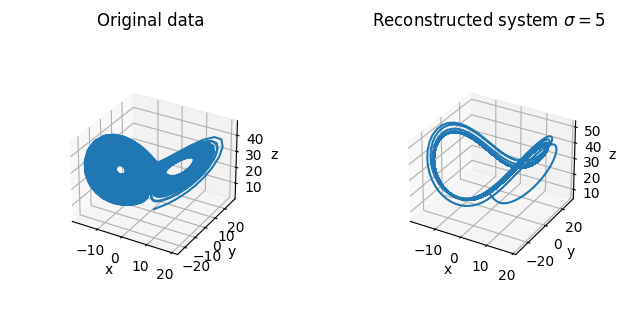

In [266]:
fig = plt.figure(figsize=(8,6))
ax=fig.add_subplot(1,2,1,projection='3d')
ax.plot(X1[:,0],
       X1[:,1],
       X1[:,2])
ax.set_title('Original data')
ax.set(xlabel = 'x',ylabel='y',zlabel='z')
ax.dist = 15
ax=fig.add_subplot(1,2,2,projection='3d')
ax.plot(Ahat1.y[0,:],
       Ahat1.y[1,:],
       Ahat1.y[2,:])
ax.set_title(r'Reconstructed system $\sigma = 5$')
ax.set(xlabel = 'x',ylabel='y',zlabel='z')
ax.dist = 15


In [244]:
A1

array([[ 0.07010049,  2.22460794,  0.9398134 ],
       [ 1.79778792,  0.74480418,  0.66000383],
       [ 4.56753005,  2.8398872 , -0.83084913],
       ...,
       [ 3.13080683,  4.72718994, 22.3672634 ],
       [ 4.500723  , -0.47905316, 21.96637776],
       [ 6.4088547 ,  4.43122622, 22.46706019]])

# f) Use the data to find a dynamical solution

In [14]:
import pandas as pd

In [15]:
whoami = pd.read_csv('whoami.csv',header=None)

In [16]:
whoami.head(5)

,0,1,2,3,4,5
0,0.374515,-5.274384,-0.020238,5.294621,-0.152923,-1.511060
1,0.480734,-5.276384,-0.050608,5.326991,-0.046904,-1.525598
2,0.587582,-5.276254,-0.081243,5.357498,0.059957,-1.537854
3,0.695021,-5.273980,-0.112103,5.386083,0.167623,-1.547681
4,0.803012,-5.269544,-0.143137,5.412681,0.276058,-1.555043


In [17]:
A = whoami.to_numpy()

In [18]:
U = A[:,0:3]
Udot = A[:,3:]


In [106]:
Theta2 = np.zeros((N+1,20))
Theta2[:,0] = 1
xx,yy,zz = U[:,0],U[:,1],U[:,2]
Theta2[:,1:4] = U #X^P1
Theta2[:,4:10] = np.array([xx**2,yy**2,zz**2,xx*yy,xx*zz,yy*zz]).T #X^P2
Theta2[:,10:] = np.array([xx**3,yy**3,zz**3,xx**2*yy,xx**2*zz,yy**2*zz,xx*yy**2,xx*yy*zz,yy*zz**2,xx*zz**2]).T #X^P3

In [107]:
P = np.linalg.pinv(Theta2) #pseudo inverse of theta
Xi2 =np.matmul(P,Udot) #initial guess for Xi
lamb = 0.025

In [108]:
for k in range(10):
    tooSmall = np.abs(Xi2)<lamb
    Xi2[tooSmall]=0
    for l in range(3):
        survivors = ~tooSmall[:,l]
        R = np.linalg.pinv(Theta2[:,survivors])
        Xi2[survivors,l] = np.matmul(R,Udot[:,l])

In [109]:
u0 = [0.374515,5.274384,0.020238]
a = Xi2[:,0]
b = Xi2[:,1]
c = Xi2[:,2]

In [110]:
def Dynamic(t,U0):
    x,y,z = U0
    v = np.array([1,x,y,z,x**2,y**2,z**2,x*y,x*z,y*z,x**3,y**3,z**3,x**2*y,x**2*z,y**2*z,x*y**2,x*y*z,y*z**2,x*z**2])
    xdot = np.dot(a,v)
    ydot = np.dot(b,v)
    zdot = np.dot(c,v)
    return [xdot,ydot,zdot]

In [111]:
tspan = (0,T)
Uhat = solve_ivp(Dynamic,tspan,u0,atol=1,rtol=1,max_step=0.02)

Text(0.5, 0.92, 'Reconstructed system')

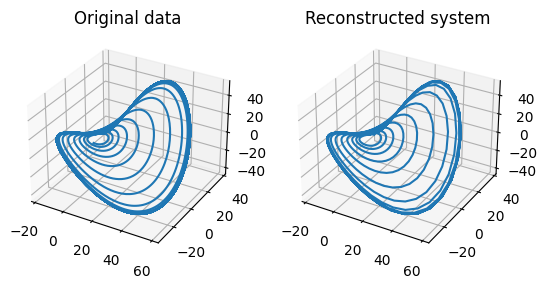

In [112]:
fig = plt.figure()
ax=fig.add_subplot(1,2,1,projection='3d')
ax.plot(U[:,0],
       U[:,1],
       U[:,2])
ax.set_title('Original data')
ax=fig.add_subplot(1,2,2,projection='3d')
ax.plot(Uhat.y[0,:],
       Uhat.y[1,:],
       Uhat.y[2,:])
ax.set_title('Reconstructed system')

In [114]:
xi3 = pd.DataFrame(Xi2,columns = [r'$\xi_1$',r'$\xi_2$',r'$\xi_3$'],
                   index = ['$1$',r'$x$',r'$y$',r'$z$',r'$x^2$',r'$y^2$',r'$z^2$',r'$xy$',r'$xz$',r'$yz$',r'$x^3$',
                            r'$y^3$',r'$z^3$',r'$x^2y$',r'$x^2z$',r'$y^2z$',r'$xy^2$',r'$xyz$',r'$yz^2$',r'$xz^2$'])
xi3

,$\xi_1$,$\xi_2$,$\xi_3$
$1$,0.0,0.0,0.1
$x$,0.0,1.0,0.0
$y$,-1.0,0.1,0.0
$z$,-1.0,0.0,-18.0
$x^2$,0.0,0.0,0.0
$y^2$,0.0,0.0,0.0
$z^2$,0.0,0.0,0.0
$xy$,0.0,0.0,1.0
$xz$,0.0,0.0,0.0
$yz$,0.0,0.0,0.0


In [146]:
u0

array([ 1.80316188,  1.77291172, -0.14250104])